# **Simple Linear Regression**



### **TvMarketing.csv Dataset**

The **TvMarketing.csv** dataset is used to study the relationship between **TV advertising expenditure** and **product sales**. It contains information about the amount spent on **TV advertisements** and the corresponding **Sales** generated. This dataset is commonly used to understand how advertising investment influences sales and to build predictive machine learning models.

In this project, we use the **Simple Linear Regression** algorithm to predict **Sales** based on the **TV advertising budget**. The model learns the relationship between the independent feature (**TV**) and the dependent variable (**Sales**) and then uses this relationship to predict sales for new TV advertising budgets.

**Dataset Information**

* **Dataset Name:** TvMarketing.csv
* **Number of Records:** 200
* **Independent Feature (X):** TV
* **Target Variable (y):** Sales

**Features**

| Feature   | Description                                                                   |
| --------- | ----------------------------------------------------------------------------- |
| **TV**    | Amount spent on TV advertisements (Independent Variable)                      |
| **Sales** | Product sales corresponding to the TV advertising budget (Dependent Variable) |

**Objective**

The objective of this project is to build a **Simple Linear Regression** model that learns the relationship between **TV advertising budget** and **Sales**. After training the model, we evaluate its performance using regression metrics such as **MAE**, **MSE**, **RMSE**, **R² Score**, and **Adjusted R² Score**. Finally, the trained model is used to predict sales for new TV advertising budgets.

**Example**

| TV Advertisement Budget | Sales |
| ----------------------: | ----: |
|                   230.1 |  22.1 |
|                    44.5 |  10.4 |
|                    17.2 |   9.3 |
|                   151.5 |  18.5 |
|                   180.8 |  12.9 |

In this project, the machine learning model learns the relationship between **TV advertising budget** and **Sales**, enabling it to estimate future sales for new advertising budgets.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# **Read the Dataset**

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Yashappin/Machine-Learning/master/TvMarketing.csv")

In [ ]:
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


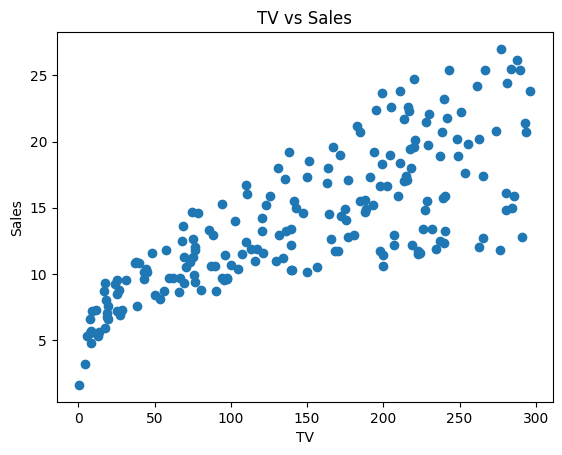

In [ ]:
plt.scatter(df['TV'],df['Sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [ ]:
df.shape

(200, 2)

In [ ]:
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [ ]:
df.isnull().sum()

,0
TV,0
Sales,0


# **Divide Dataset into Independent and Dependent Features**

In [ ]:
X = df[['TV']]  # independent feature (always in 2D)
y = df['Sales'] # Dependent feature

In [ ]:
X.shape, y.shape

((200, 1), (200,))

# **Slipt Dataset into train and Test**



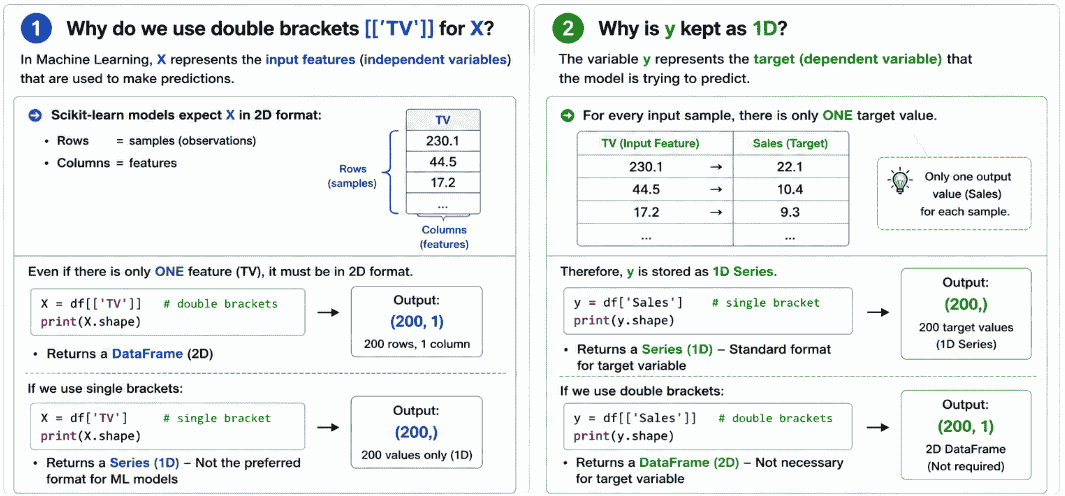

In [ ]:
from sklearn.model_selection import train_test_split

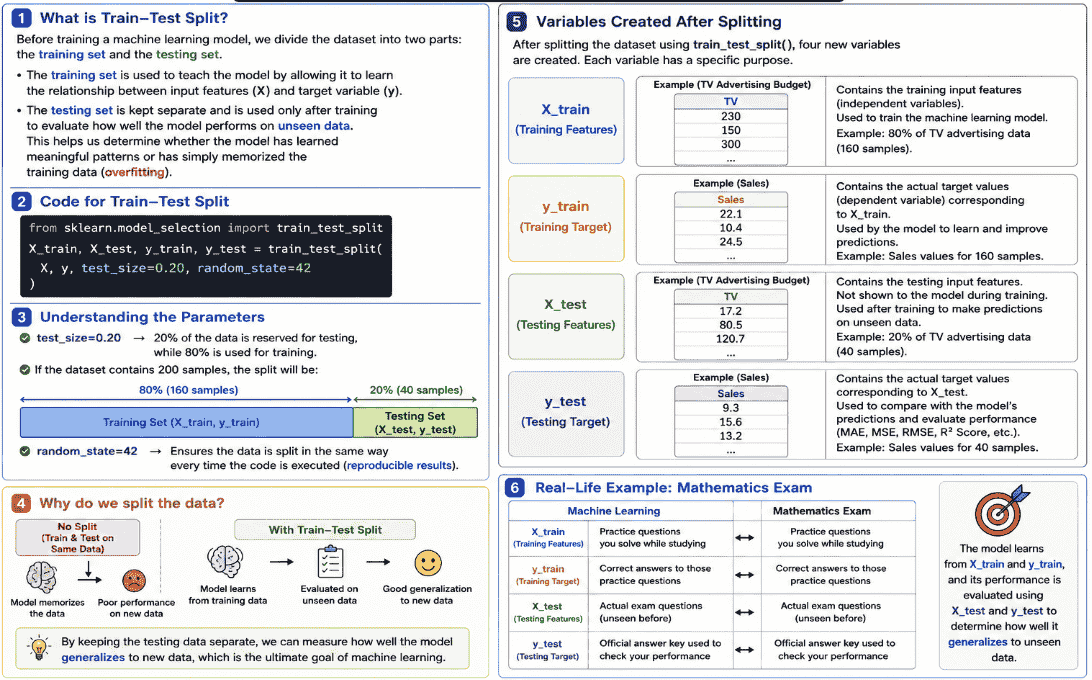


After splitting the dataset using `train_test_split()`, four new variables are created. Each variable has a specific purpose in the machine learning workflow.

`X_train`

`X_train` contains the **training input features (independent variables)**. It is used to **train the machine learning model**. The model learns the relationship between the input features (`X`) and the target variable (`y`) using this data.

For example, if the dataset contains the `TV` advertising budget as the input feature, `X_train` will contain **80% of the TV advertising data**.

---

`y_train`

`y_train` contains the **actual target values (dependent variable)** corresponding to `X_train`. These are the correct answers that the model uses during training. The model compares its predicted values with these actual values and learns how to improve its predictions.

For example, if `X_train` contains the TV advertising budgets, then `y_train` contains the corresponding sales values.

---

`X_test`

`X_test` contains the **testing input features**. This data is **not shown to the model during training**. After the model has finished learning, `X_test` is used to make predictions on **new, unseen data**.

This helps us evaluate how well the model performs on data it has never seen before.

---

`y_test`

`y_test` contains the **actual target values** corresponding to `X_test`. After the model predicts the output for `X_test`, these predictions are compared with `y_test` to measure the model's performance using evaluation metrics such as **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

**`test_size=0.20`**

The `test_size` parameter specifies the proportion of data that should be used for **testing**.

```python
test_size = 0.20
```

means

* **80%** of the data is used for training.
* **20%** of the data is used for testing.

Since the dataset contains **200 records**:

* Training Data = **160 samples**
* Testing Data = **40 samples**

---

**`random_state=42`**

The `random_state` parameter controls the **random splitting** of the dataset.

```python
random_state = 42
```

ensures that the dataset is split in the **same way every time** the code is executed.

This makes the experiment **reproducible**, meaning anyone running the same code will get the exact same training and testing datasets.

If `random_state` is not specified, the dataset will be randomly split every time the code is executed, which may produce slightly different results.

> **Why 42?**
>
> There is no special mathematical meaning behind **42**. It is simply a commonly used random seed in programming. You can use any integer, such as `0`, `10`, `100`, or `123`. The important point is to use the **same value** whenever you want reproducible results.


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 1), (40, 1), (160,), (40,))

In [ ]:
X_train

,TV
79,116.0
197,177.0
38,43.1
24,62.3
122,224.0
...,...
106,25.0
14,204.1
92,217.7
179,165.6


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scalar =  StandardScaler()

In [ ]:
X_train_scalar = scalar.fit_transform(X_train)

In [ ]:
X_test_scalar = scalar.transform(X_test)

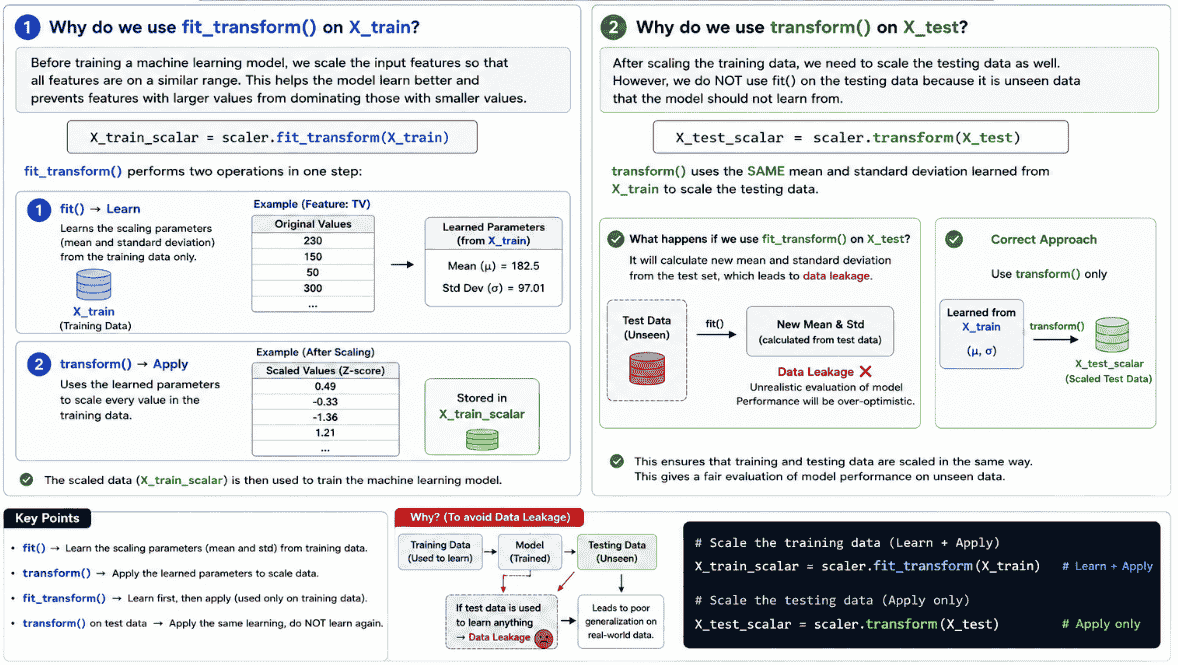

In [ ]:
X_train_scalar

array([[-0.40424839],
       [ 0.32060772],
       [-1.27051084],
       [-1.04235941],
       [ 0.8791034 ],
       [-1.32873699],
       [-0.94373145],
       [-0.03231403],
       [-0.5397133 ],
       [-0.875999  ],
       [-0.85342151],
       [ 0.21841489],
       [-1.67928215],
       [-1.68997675],
       [-0.87481071],
       [-0.2450177 ],
       [-0.91045937],
       [ 1.65980907],
       [-1.54975868],
       [ 0.56539519],
       [ 1.59564148],
       [ 0.41448252],
       [-0.44108534],
       [-1.49985056],
       [ 1.67169196],
       [-1.55213526],
       [ 1.70615233],
       [-1.56045328],
       [-0.18679156],
       [-1.47846136],
       [-0.58962142],
       [-0.82965574],
       [ 0.45607263],
       [ 0.32060772],
       [-0.28898438],
       [ 0.70798983],
       [-0.08459873],
       [ 0.41448252],
       [ 0.86009078],
       [ 1.0894305 ],
       [-1.57827761],
       [-0.35077539],
       [-0.71676831],
       [ 0.48815642],
       [-0.88550531],
       [ 0

In [ ]:
X_test_scalar

array([[ 0.15781217],
       [ 0.53925283],
       [ 1.69783431],
       [-1.64363349],
       [ 0.83513672],
       [-0.89025846],
       [ 0.79354661],
       [-1.18851892],
       [ 0.86009078],
       [ 0.29803023],
       [-1.40835233],
       [-1.11484502],
       [ 1.00387371],
       [-1.71849568],
       [-0.12500054],
       [ 0.23980408],
       [-1.69591819],
       [ 0.56539519],
       [-0.88788188],
       [ 1.03833409],
       [ 0.94445928],
       [-0.97700354],
       [-1.33111357],
       [ 1.19875306],
       [-0.96274407],
       [-1.14692882],
       [ 0.75433309],
       [-0.12737712],
       [-0.74647553],
       [-1.68284702],
       [ 0.59153754],
       [-0.96036749],
       [ 0.58084294],
       [-1.58184248],
       [ 1.55286309],
       [ 1.04784039],
       [-1.20871983],
       [ 1.46968288],
       [-0.38998892],
       [-1.45588388]])

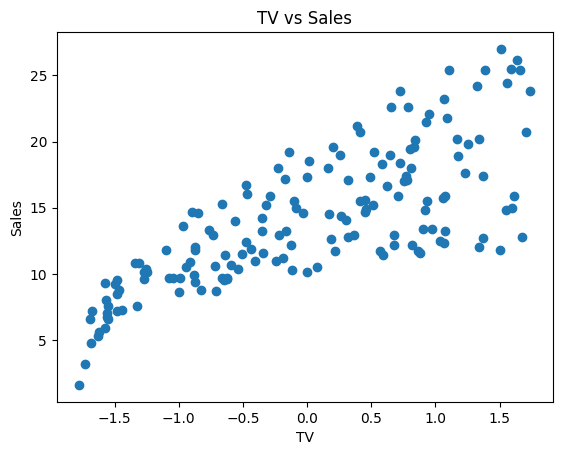

In [ ]:
plt.scatter(X_train_scalar,y_train)
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.show()

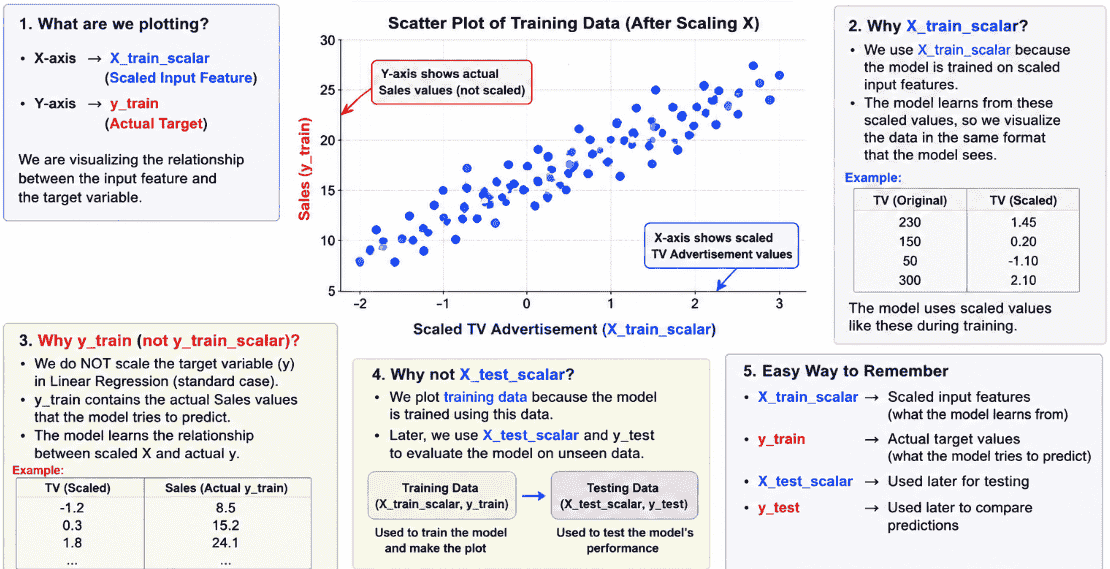

# **Model Training**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
regression = LinearRegression()

**Training Trained Data**

In [ ]:
regression.fit(X_train_scalar,y_train)

LinearRegression()

During this step, the model learns the relationship between the **input feature (`X_train_scalar`)** and the **target variable (`y_train`)**. The `fit()` method analyzes the training data and finds the **best-fit line** that minimizes the prediction error. In other words, the model learns the optimal values of the **slope (coefficient)** and the **intercept (bias)** so that it can accurately predict the target variable for new data.

We use **`X_train_scalar`** instead of `X_train` because the input features have already been scaled using `StandardScaler`. Training the model on scaled data helps many machine learning algorithms perform more efficiently and ensures that all features are on the same scale. We use **`y_train`** because it contains the **actual target values (Sales)** corresponding to each training sample. The model compares the input features with these actual target values to learn the relationship between them. During training, the model does **not memorize the data**; instead, it learns a mathematical equation that best represents the relationship between the input and the output.

After the `fit()` method completes, the model has learned the optimal values of the coefficient (`β₁`) and intercept (`β₀`). These learned parameters are stored inside the `regression` object and are later used to make predictions on unseen data using the `predict()` method.



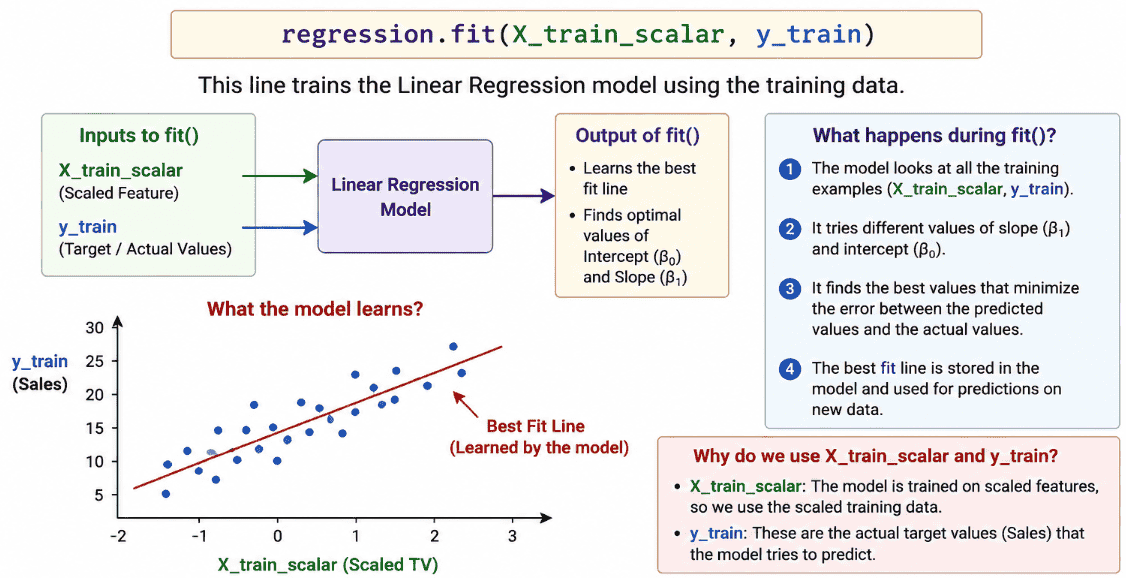

In [ ]:
# intercept
regression.intercept_

np.float64(14.100000000000001)

In [ ]:
# Slope
regression.coef_

array([3.91569271])

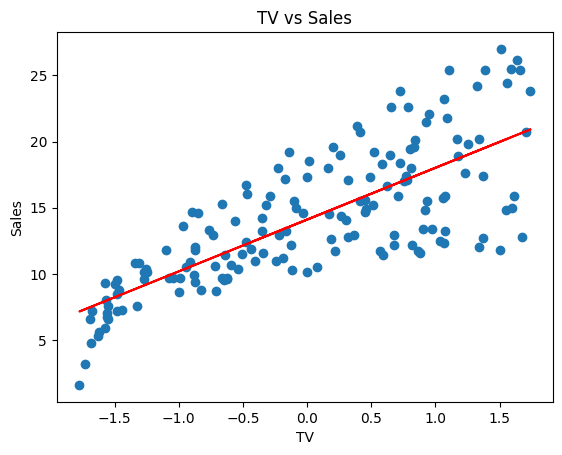

In [ ]:
plt.scatter(X_train_scalar,y_train)
plt.plot(X_train_scalar,regression.predict(X_train_scalar),color='red')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.show()


## Plotting the Best-Fit Line

After training the Linear Regression model using `regression.fit(X_train_scalar, y_train)`, the model has learned the relationship between the input feature and the target variable. The statement:

```python
plt.plot(X_train_scalar, regression.predict(X_train_scalar), color='red')
```

is used to **draw the best-fit line** on the graph. The `regression.predict(X_train_scalar)` method generates the **predicted values (`ŷ`)** for every input value in `X_train_scalar`. These predicted values lie on the regression line learned by the model. The `plt.plot()` function then connects these predicted points with a red line, resulting in the **best-fit line**.

The red line represents the model's prediction for every input value, while the blue scatter points (drawn using `plt.scatter(X_train_scalar, y_train)`) represent the **actual training data**. By comparing the scatter points with the red line, we can visually see how well the model fits the data. If the points are close to the red line, it indicates that the model has learned the relationship well. If many points are far away from the line, it suggests that the prediction errors are larger.


---

### What actually happens?

Suppose the training data is:

| X_train_scalar | y_train (Actual Sales) |
| -------------: | ---------------------: |
|           -2.0 |                      5 |
|           -1.0 |                     10 |
|            0.0 |                     15 |
|            1.0 |                     20 |
|            2.0 |                     25 |

After training, the model predicts:

| X_train_scalar | `regression.predict(X_train_scalar)` |
| -------------: | -----------------------------------: |
|           -2.0 |                                  5.2 |
|           -1.0 |                                  9.8 |
|            0.0 |                                 15.1 |
|            1.0 |                                 20.3 |
|            2.0 |                                 24.9 |

When you run:

```python
plt.scatter(X_train_scalar, y_train)                     # Blue dots (Actual values)
plt.plot(X_train_scalar,
         regression.predict(X_train_scalar),
         color='red')                                    # Red best-fit line
```


The **red line** is the line that the model learned during training and uses to make predictions for new data.


# **Prediction for the test data**

In [ ]:
y_pred = regression.predict(X_test_scalar)



### Making Predictions on the Test Data

After training the Linear Regression model using the training data, the next step is to check how well it performs on **new, unseen data**. The statement:

```python
y_pred = regression.predict(X_test_scalar)
```

uses the trained model to predict the target values for the testing data. The `predict()` method takes the **scaled testing features (`X_test_scalar`)** as input and applies the mathematical relationship learned during training to generate the **predicted target values**. These predicted values are stored in the variable `y_pred`.



The variable **`y_pred`** contains the model's estimated values, while **`y_test`** contains the actual values from the dataset. These two are compared to evaluate the performance of the model using metrics such as **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**.




In [ ]:
y_pred

array([14.71794394, 16.2115484 , 20.74819743,  7.66403631, 17.37013877,
       10.61402143, 17.2072847 ,  9.44612512, 17.46785121, 15.2669948 ,
        8.58532504,  9.73460946, 18.03086098,  7.37089899, 13.61053628,
       15.03899911,  7.45930549, 16.31391381, 10.62332738, 18.16579721,
       17.79821232, 10.27435438,  8.88776831, 18.79394862, 10.33019006,
        9.60897918, 17.05373658, 13.60123034, 11.17703121,  7.51048819,
       16.41627922, 10.339496  , 16.37440246,  7.90599093, 20.18053468,
       18.203021  ,  9.36702457, 19.85482655, 12.57292322,  8.39920611])

**Performance Metrics**

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [ ]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",np.sqrt(mse))

Mean Squared Error:  10.204654118800955
Mean Absolute Error:  2.444420003751042
Root Mean Squared Error:  3.194472431998898




### **Evaluating the Linear Regression Model**

After the model predicts the target values using `y_pred = regression.predict(X_test_scalar)`, the next step is to evaluate how well these predictions match the actual values (`y_test`). This is done using evaluation metrics such as **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, and **Root Mean Squared Error (RMSE)**. These metrics measure the difference between the predicted values and the actual values. A **smaller value** indicates that the model's predictions are closer to the actual values and, therefore, the model is performing better.

---

**1. Mean Absolute Error (MAE)**

Model produced:

```text
Mean Absolute Error = 2.44
```

This means that, on average, the model's predictions are approximately **2.44 Sales units away from the actual Sales values**. Since MAE is measured in the **same unit as the target variable**, it is easy to interpret.

---

**2. Mean Squared Error (MSE)**

The **Mean Squared Error (MSE)** measures the average of the **squared differences** between the actual and predicted values. Squaring the errors gives **more importance to larger errors**, making MSE useful when we want the model to be penalized more for large mistakes.

Model produced:

```text
Mean Squared Error = 10.20
```

This means that the average squared prediction error is **10.20**. Because the errors are squared, the unit of MSE is also squared, making it less intuitive to interpret directly.

---

**3. Root Mean Squared Error (RMSE)**

Taking the square root converts the error back to the **original unit of the target variable**, making it much easier to understand.

Model produced:

```text
Root Mean Squared Error = 3.19
```

This means that the model's predictions differ from the actual Sales values by approximately **3.19 Sales units** on average. Since RMSE penalizes larger errors more than MAE, it is often preferred when large prediction errors are particularly undesirable.

---


* **MAE** → Average prediction error.
* **MSE** → Average **squared** prediction error (penalizes large errors more).
* **RMSE** → Square root of MSE, expressed in the **same unit** as the target variable.
---

* **MAE** → "How wrong am I on average?"
* **MSE** → "How severely should I punish large mistakes?"
* **RMSE** → "How wrong am I on average, in the original unit?"


In [ ]:
# Accuracy of the model R Squared and Adjusted R Squared
from sklearn.metrics import r2_score

In [ ]:
r2_score = regression.score(X_test_scalar,y_test)
print("R2 Score: ",r2_score)

R2 Score:  0.6766954295627077


In [ ]:
# Adjusted R Squared
1 - (1-r2_score)*(len(y_test)-1)/(len(y_test)-X_test_scalar.shape[1]-1)

0.6681874145511999

**R² Score**

Model produced:

```text
R² Score = 0.6767
```

This means that **67.67% of the variation in Sales can be explained by the TV advertising budget**, while the remaining **32.33%** is due to other factors that are not included in the model, such as Radio advertising, Newspaper advertising, customer behavior, seasonal trends, or random variation.

An R² Score closer to **1** indicates a better model because it explains more of the variation in the target variable. An R² Score close to **0** means the model does not explain the data well.

---

**Adjusted R² Score**



The formula used is:

```python
Adjusted_R2 = 1 - ((1 - R²) × (n - 1)) / (n - p - 1)
```

where:

* **n** = Number of samples in the testing dataset.
* **p** = Number of input features.

Model produced:

```text
Adjusted R² Score = 0.6682
```

This value is slightly lower than the R² Score because the Adjusted R² Score considers both the model's performance and its complexity. Since your model has only **one input feature (TV)**, the difference between R² and Adjusted R² is very small.



# **Comparing Actual vs Predicted**

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
95,16.9,14.717944
15,22.4,16.211548
30,21.4,20.748197
158,7.3,7.664036
128,24.7,17.370139
115,12.6,10.614021
69,22.3,17.207285
170,8.4,9.446125
174,11.5,17.467851
45,14.9,15.266995


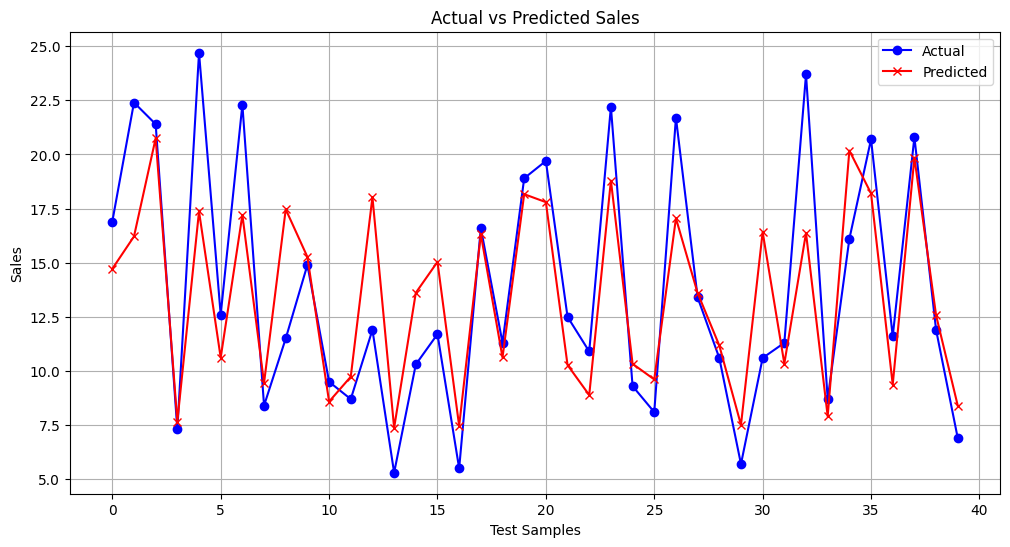

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual", color="blue", marker="o")
plt.plot(y_pred, label="Predicted", color="red", marker="x")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

# **Predicting on New Data**

Suppose a company asks: "If we spend $250 on TV advertisements, how much Sales can we expect?"

This is where the trained model is actually used.

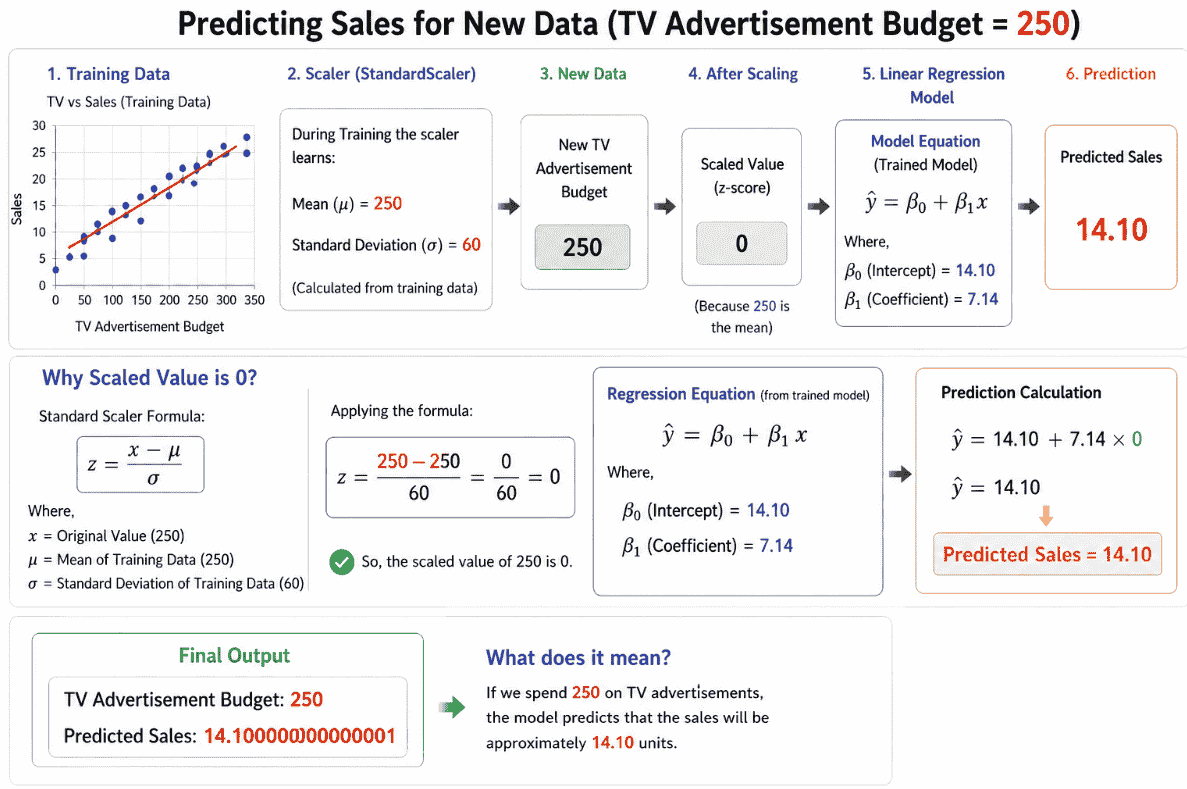

In [ ]:
# Step 1: Create the new data, Here, 250 is the new TV advertising budget.
new_data = [[250]]

In [ ]:
# Step 2: Scale the new data

# Since the model was trained on scaled data, the new input must also be scaled
# using the same scaler.

new_data_scaled = scaler.transform(new_data)

Important: We use `transform()`, not `fit_transform()`, because the scaler has already learned the mean and standard deviation from the training data.

In [ ]:
# Predict Sales
predicted_sales = regression.predict(new_data_scaled)

print("TV Advertisement Budget:", new_data[0][0])
print("Predicted Sales:", predicted_sales[0])

TV Advertisement Budget: 250
Predicted Sales: 14.100000000000001


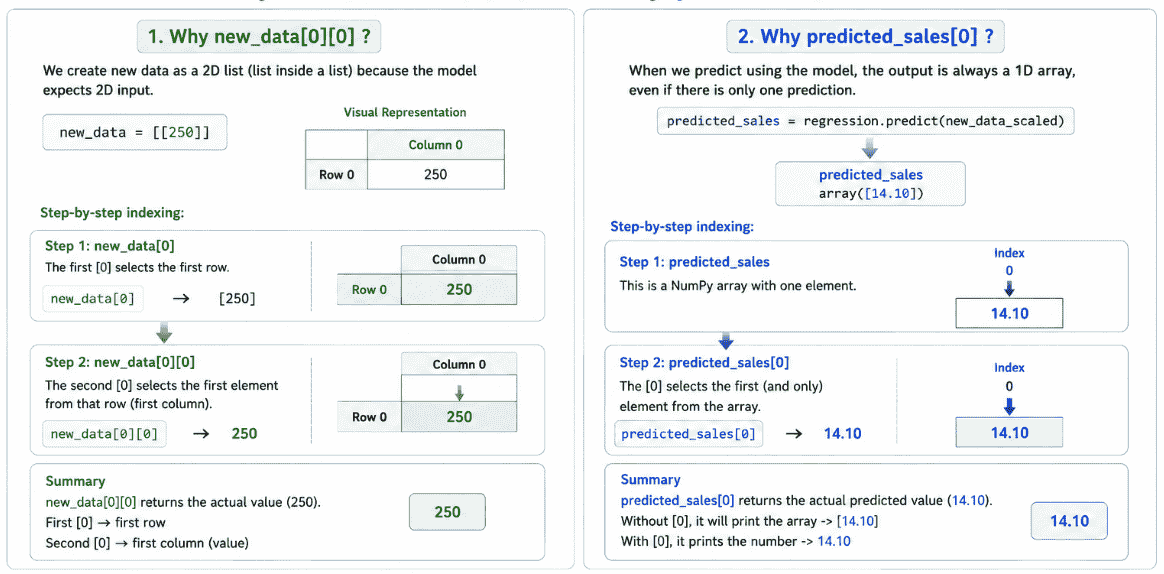